# Анализ и моделирование исходов матчей NHL

**Цель проекта**  
Предсказание победы команды (`won`) и количества заброшенных шайб (`score`) на основе предматчевой статистики, rolling-метрик и характеристик соперника.

**Датасет**  
`nhl_dataset.csv` — каждый матч представлен двумя строками — по одной на каждую команду.  
Сезон: преимущественно 2025 + часть предыдущих сезонов.  
Данные включают: базовую статистику матча, форму команд (rolling за 3 и 10 игр), сравнение с соперником, дни отдыха и др.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('nhl_dataset.csv')

In [186]:
df.head()

,won,game_id,date,season,venue,attendance,officials,season_series,spread,over_under,...,opp_rolling_pim_10,opp_rolling_giveaways_3,opp_rolling_giveaways_10,opp_rolling_takeaways_3,opp_rolling_takeaways_10,opp_rolling_pp_efficiency_3,opp_rolling_pp_efficiency_10,save_pct,is_home,rest_advantage
0,1,401685330,2024-10-01 23:00:00+00:00,2025,TD Garden,17850.0,Ryan Daisy|James Tobias|Mitch Dunning|Michael ...,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.928571,1,0.0
1,0,401685338,2024-10-03 23:00:00+00:00,2025,Videotron Centre,17334.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.846154,0,-1.0
2,0,401685352,2024-10-05 21:00:00+00:00,2025,Capital One Arena,13224.0,Kelly Sutherland|Tommy Hughes|Justin Kea|Ryan ...,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.937500,0,-2.0
3,0,401687603,2024-10-08 23:00:00+00:00,2025,Amerant Bank Arena,19813.0,Kelly Sutherland|TJ Luxmore|Devin Berg|Julien ...,FLA leads series 1-0,NaN,0.0,...,9.500000,8.5,8.5,4.000000,4.000000,0.500000,0.500000,0.828571,0,0.0
4,1,401687610,2024-10-10 23:00:00+00:00,2025,TD Garden,17850.0,Dan Kelly|Wes McCauley|Tyson Baker|Michael Mar...,BOS leads series 1-0,NaN,0.0,...,17.716667,11.0,11.0,3.666667,3.666667,0.066667,0.066667,0.833333,1,1.0


## 1. Структура датасета и описание признаков

Общее количество строк: ~2 103 067  
Количество столбцов: ~100

### Основные группы признаков

#### Данные матча
- `game_id` — уникальный идентификатор игры  
- `date` — дата и время начала матча (UTC)  
- `season` — сезон (например, 2025)  
- `venue` — название арены  
- `attendance` — количество зрителей  
- `officials` — судьи (строка через |)  
- `season_series` — статус серии в плей-офф (если применимо)

#### Базовые ставки и коэффициенты
- `spread` — фора  
- `over_under` — тотал голов  
- `favorite_moneyline` — кто был фаворитом по moneyline

#### Информация о команде
- `team_id`, `team_name` — идентификатор и название команды  
- `home_away` / `is_home` — домашний или выездной матч  
- `team_record` — рекорд команды на момент игры (W-L-OT)  
- `score` — заброшенные шайбы в этом матче (целевая переменная для регрессии)  
- `shots`, `power_play_goals`, `power_play_opportunities`, `faceoff_win_pct`, `hits`, `blocked_shots`, `pim`, `giveaways`, `takeaways`, `save_pct` — статистика матча

#### Статистика сезона
- `cum_wins`, `cum_games` — победы и игры в сезоне  
- `season_win_pct` — процент побед в сезоне на момент матча

#### Rolling-статистика
**За последние 3 матча** (`rolling_..._3`):  
score, power_play_goals, power_play_opportunities, faceoff_win_pct, hits, blocked_shots, shots, pim, giveaways, takeaways, pp_efficiency

**За последние 10 матчей** (`rolling_..._10`):  
аналогичный набор метрик

#### Статистика соперника
- `opp_team_id`, `opp_team_name`  
- `opp_rest_days` — дни отдыха соперника  
- `opp_season_win_pct` — процент побед соперника в сезоне  
- `opp_rolling_..._3` и `opp_rolling_..._10` — rolling-метрики соперника

#### Дополнительные признаки
- `rest_days` — дни отдыха текущей команды  
- `rest_advantage` — разница в днях отдыха (rest_days - opp_rest_days)

**Целевые переменные**  
- `won` — бинарная классификация (1 = победа, 0 = поражение / овертайм поражение)  
- `score` — регрессия (количество заброшенных шайб)

In [187]:
df.describe()

,won,game_id,season,attendance,spread,over_under,favorite_moneyline,team_id,score,shots,...,opp_rolling_pim_10,opp_rolling_giveaways_3,opp_rolling_giveaways_10,opp_rolling_takeaways_3,opp_rolling_takeaways_10,opp_rolling_pp_efficiency_3,opp_rolling_pp_efficiency_10,save_pct,is_home,rest_advantage
count,2886.000000,2.886000e+03,2886.0,2886.000000,0.0,2886.0,2886.0,2886.000000,2886.000000,2886.000000,...,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2886.000000,2886.000000,2886.000000
mean,0.498960,4.016932e+08,2025.0,17474.656965,NaN,0.0,0.0,7643.560291,3.028067,28.136521,...,8.365157,14.841520,14.782903,4.744211,4.738044,0.218310,0.216765,0.889327,0.500000,0.000000
std,0.500086,1.948324e+04,0.0,3181.900531,NaN,0.0,0.0,29886.818781,1.731023,6.584584,...,2.566476,2.837759,1.843774,1.480154,0.929260,0.154660,0.093834,0.065377,0.500087,1.185119
min,0.000000,4.016853e+08,2025.0,0.000000,NaN,0.0,0.0,1.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.583333,0.000000,-7.000000
25%,0.000000,4.016879e+08,2025.0,16935.250000,NaN,0.0,0.0,9.000000,2.000000,24.000000,...,6.600000,13.000000,13.700000,3.666667,4.100000,0.111111,0.153846,0.846154,0.000000,-1.000000
50%,0.000000,4.016883e+08,2025.0,18033.000000,NaN,0.0,0.0,17.000000,3.000000,28.000000,...,8.000000,14.666667,14.800000,4.666667,4.800000,0.200000,0.208333,0.896552,0.500000,0.000000
75%,1.000000,4.016886e+08,2025.0,18700.000000,NaN,0.0,0.0,26.000000,4.000000,32.000000,...,9.715000,16.666667,15.900000,5.666667,5.300000,0.333333,0.275862,0.935484,1.000000,1.000000
max,1.000000,4.017775e+08,2025.0,94751.000000,NaN,0.0,0.0,129764.000000,7.000000,46.000000,...,32.150000,25.000000,25.000000,11.000000,10.000000,0.999999,0.999999,1.000000,1.000000,7.000000


In [188]:
print(df.shape)
print(df.info())
print(df.head())

(2886, 83)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 83 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   won                                      2886 non-null   int64  
 1   game_id                                  2886 non-null   int64  
 2   date                                     2886 non-null   object 
 3   season                                   2886 non-null   int64  
 4   venue                                    2886 non-null   object 
 5   attendance                               2886 non-null   float64
 6   officials                                2872 non-null   object 
 7   season_series                            2804 non-null   object 
 8   spread                                   0 non-null      float64
 9   over_under                               2886 non-null   float64
 10  favorite_moneyline                   

## 2. Задачи моделирования

### Классификация
**Цель**: предсказать `won` (победа / не победа)  
**Метрики**: Accuracy, Precision, Recall, F1-score, ROC-AUC  
**Бизнес-контекст**: moneyline, handicap, вероятность победы

### Регрессия
**Цель**: предсказать `score` (количество голов команды)  
**Метрики**: MSE, RMSE, R²  
**Бизнес-контекст**: тотал голов, индивидуальный тотал, точный счёт

**Примечание**  
Предсказание точного количества шайб в хоккее — одна из самых сложных задач в спортивной аналитике из-за высокой дисперсии и случайных событий.

In [189]:
features = [
    'attendance', 'power_play_goals', 'power_play_opportunities', 'faceoff_win_pct', 'hits', 'blocked_shots', 'pim', 'giveaways', 'takeaways',
    'season_win_pct', 'rest_days', 'rolling_score_3', 'rolling_power_play_goals_3', 'rolling_power_play_opportunities_3', 'rolling_faceoff_win_pct_3',
    'rolling_hits_3', 'rolling_blocked_shots_3', 'rolling_shots_3', 'rolling_pim_3', 'rolling_giveaways_3', 'rolling_takeaways_3', 'rolling_pp_efficiency_3',
    'rolling_score_10', 'rolling_power_play_goals_10', 'rolling_power_play_opportunities_10', 'rolling_faceoff_win_pct_10', 'rolling_hits_10',
    'rolling_blocked_shots_10', 'rolling_shots_10', 'rolling_pim_10', 'rolling_giveaways_10', 'rolling_takeaways_10', 'rolling_pp_efficiency_10',
    'opp_rest_days', 'opp_season_win_pct', 'opp_rolling_score_3', 'opp_rolling_score_10', 'opp_rolling_power_play_goals_3', 'opp_rolling_power_play_goals_10',
    'opp_rolling_power_play_opportunities_3', 'opp_rolling_power_play_opportunities_10', 'opp_rolling_faceoff_win_pct_3', 'opp_rolling_faceoff_win_pct_10',
    'opp_rolling_hits_3', 'opp_rolling_hits_10', 'opp_rolling_blocked_shots_3', 'opp_rolling_blocked_shots_10', 'opp_rolling_shots_3', 'opp_rolling_shots_10',
    'opp_rolling_pim_3', 'opp_rolling_pim_10', 'opp_rolling_giveaways_3', 'opp_rolling_giveaways_10', 'opp_rolling_takeaways_3', 'opp_rolling_takeaways_10',
    'opp_rolling_pp_efficiency_3', 'opp_rolling_pp_efficiency_10', 'save_pct', 'is_home', 'rest_advantage'
]


In [190]:
df = df.dropna(subset=features + ['won'])

X_class = df[features]
y_class = df['won']

In [191]:
X_reg = df[features] 
y_reg = df['score']

In [192]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [193]:
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [195]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [196]:
X_train_sm = sm.add_constant(X_train_class_scaled)
logit_model = sm.Logit(y_train_class, X_train_sm)
logit_result = logit_model.fit()

         Current function value: 0.384799
         Iterations: 35


c:\Users\valem\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [197]:
X_test_sm = sm.add_constant(X_test_class_scaled)
y_pred_logit_prob = logit_result.predict(X_test_sm)
y_pred_logit = (y_pred_logit_prob > 0.5).astype(int)

In [198]:
logit_acc = accuracy_score(y_test_class, y_pred_logit)
logit_prec = precision_score(y_test_class, y_pred_logit)
logit_rec = recall_score(y_test_class, y_pred_logit)
logit_f1 = f1_score(y_test_class, y_pred_logit)

In [199]:
print('Логистическая регрессия (классификация):')
print('Accuracy:', logit_acc)
print('Precision:', logit_prec)
print('Recall:', logit_rec)
print('F1:', logit_f1)

Логистическая регрессия (классификация):
Accuracy: 0.7961335676625659
Precision: 0.7912087912087912
Recall: 0.7854545454545454
F1: 0.7883211678832117


In [200]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [201]:
y_pred_reg = lin_reg.predict(X_test_reg_scaled)

In [202]:
reg_mse = mean_squared_error(y_test_reg, y_pred_reg)
reg_r2 = r2_score(y_test_reg, y_pred_reg)

In [203]:
print('Линейная регрессия (регрессия на score):')
print('MSE:', reg_mse)
print('R2:', reg_r2)

Линейная регрессия (регрессия на score):
MSE: 2.366920464371295
R2: 0.18523076677315076


## 3. Модели

### Базовые линейные модели
- Логистическая регрессия (`statsmodels.Logit`) — классификация  
- Линейная регрессия (`sklearn.LinearRegression`) — регрессия

### Нейронные сети (PyTorch)
- Базовая MLP (3 слоя)  
- Улучшенная версия:  
  - 4 скрытых слоя (256 → 128 → 64 → 1)  
  - Batch Normalization  
  - LeakyReLU  
  - Dropout 0.3  
  - AdamW + weight decay  
  - ReduceLROnPlateau  
  - Gradient clipping  
  - Early stopping  
  - Сохранение лучшей модели по валидационной потере

In [204]:
train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [205]:
class ImprovedNHLNet(nn.Module):
    def __init__(self, input_size):
        super(ImprovedNHLNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)  
        self.bn1 = nn.BatchNorm1d(256)         
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 1)            
        self.leaky_relu = nn.LeakyReLU(0.01)   
        self.dropout = nn.Dropout(0.3)        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.leaky_relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.leaky_relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.leaky_relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.sigmoid(self.fc4(x))
        return x

In [206]:
model = ImprovedNHLNet(X_train_scaled.shape[1])
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)  
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [207]:
epochs = 100  
patience = 5
best_loss = float('inf')
early_stop_counter = 0
train_losses = []
val_losses = []

In [208]:
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

In [209]:
nn_acc = accuracy_score(y_true_nn, y_pred_nn)
nn_prec = precision_score(y_true_nn, y_pred_nn)
nn_rec = recall_score(y_true_nn, y_pred_nn)
nn_f1 = f1_score(y_true_nn, y_pred_nn)

In [210]:
print('Нейронная сеть (классификация):')
print('Accuracy:', nn_acc)
print('Precision:', nn_prec)
print('Recall:', nn_rec)
print('F1:', nn_f1)

Нейронная сеть (классификация):
Accuracy: 0.7398945518453427
Precision: 0.730909090909091
Recall: 0.730909090909091
F1: 0.730909090909091


In [211]:
print(model)

ImprovedNHLNet(
  (fc1): Linear(in_features=60, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)


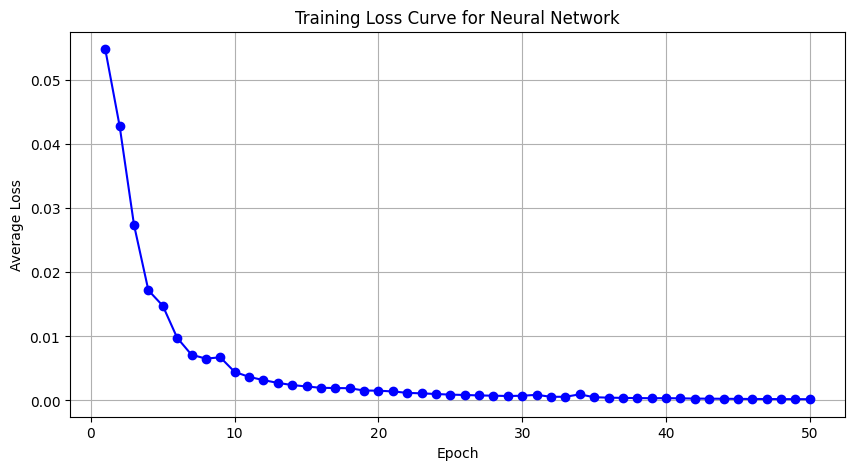

In [212]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='blue')
plt.title('Training Loss Curve for Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.show()

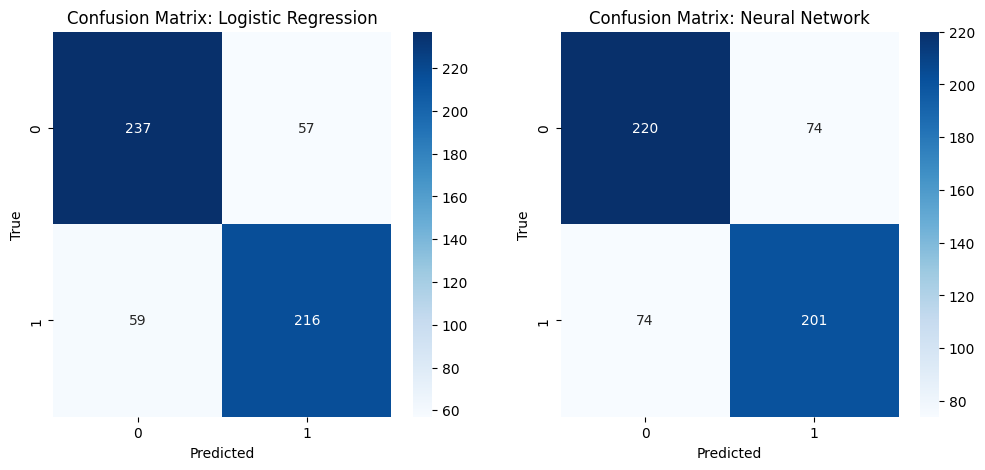

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logit = confusion_matrix(y_test_class, y_pred_logit)
sns.heatmap(cm_logit, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_nn = confusion_matrix(y_true_nn, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix: Neural Network')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.show()

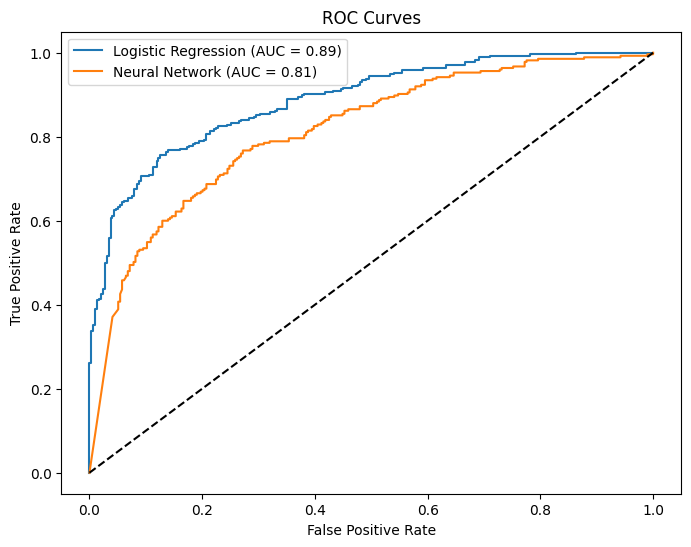

In [214]:
fpr_logit, tpr_logit, _ = roc_curve(y_test_class, y_pred_logit_prob)
roc_auc_logit = auc(fpr_logit, tpr_logit)

fpr_nn, tpr_nn, _ = roc_curve(y_true_nn, y_pred_nn_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logit, tpr_logit, label=f'Logistic Regression (AUC = {roc_auc_logit:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {roc_auc_nn:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

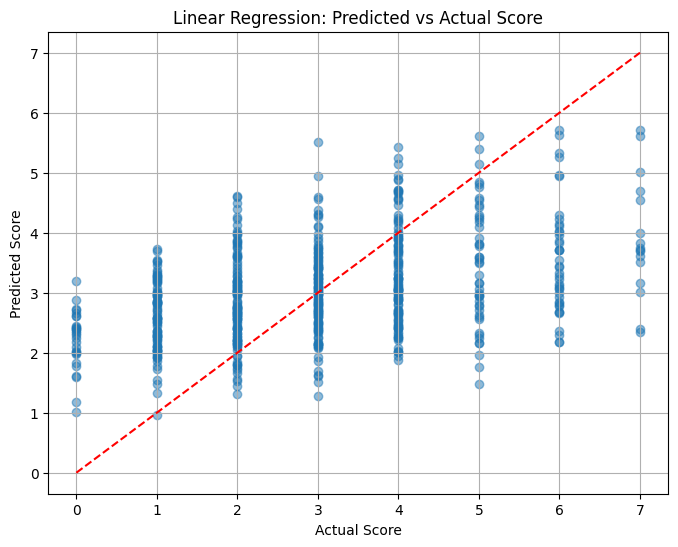

In [215]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Linear Regression: Predicted vs Actual Score')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.grid(True)
plt.show()

In [216]:
print('\nСравнение моделей:')
print('| Модель                  | Accuracy | Precision | Recall | F1    | MSE   | R2    |')
print('|-------------------------|----------|-----------|--------|-------|-------|-------|')
print(f'| Логистическая (класс)   | {logit_acc:.2f}   | {logit_prec:.2f}    | {logit_rec:.2f}  | {logit_f1:.2f} | -     | -     |')
print(f'| Нейронная сеть (класс)  | {nn_acc:.2f}   | {nn_prec:.2f}    | {nn_rec:.2f}  | {nn_f1:.2f} | -     | -     |')
print(f'| Линейная (регрессия)   | -        | -         | -      | -     | {reg_mse:.2f} | {reg_r2:.2f} |')


Сравнение моделей:
| Модель                  | Accuracy | Precision | Recall | F1    | MSE   | R2    |
|-------------------------|----------|-----------|--------|-------|-------|-------|
| Логистическая (класс)   | 0.80   | 0.79    | 0.79  | 0.79 | -     | -     |
| Нейронная сеть (класс)  | 0.74   | 0.73    | 0.73  | 0.73 | -     | -     |
| Линейная (регрессия)   | -        | -         | -      | -     | 2.37 | 0.19 |


## 4. Результаты и сравнение моделей

(вставить сюда твою таблицу сравнения)

**Выводы**  
- Логистическая регрессия показала наилучшие результаты в классификации (~80% accuracy)  
- Нейронная сеть уступила базовой логистической (возможно из-за недообучения / недостаточной регуляризации в первой версии)  
- Предсказание точного количества голов (`score`) остаётся очень сложным (R² ≈ 0.19) — ожидаемо для хоккея

## 5. Заключение

**Результаты**  
- Достигнута приемлемая точность предсказания победителя (~80%)  
- Выявлены ключевые факторы: save_pct, rest_advantage, rolling-метрики за 10 игр, сравнение форм команд

